# BEE 4310/6310: Environmental Statistics and Learning  <br> Assignment #3 (5 pts)

**Include responses to everything below in bold (including plots), and make sure your final assignment is well organized in a single markdown PDF submitted to Canvas. This makes it easier to grade (and easier to give partial credit).**

**Remember to include an acknowledgement at the bottom of this assignment if generative AI was used for coding support, including a list of the problems for which it was used.**

**Techniques and Topics:** 
- Neural Networks


In this assignment, we will use neural networks to predict large wildfire occurrences using a real-world dataset that combines U.S. Forest Service wildfire occurrence data with meteorological observations.

The problems below walk you through building a neural network from scratch, and comparing your hand-built model against one developed in scikit-learn. 

This assignment is purposefully similar to one given at the end of BEE 4310/6310 (Fall semester), with some small changes, in order to reinforce concepts covered at the end of last semester. 


<img src="wildfire_image.jpeg" width="500"/>

1. Import the following packages: numpy, pandas, matplotlib.pyplot. Note: you will need to import other packages further down in the assignment. 

    Download the forest_fires_subsampled.csv file from Canvas under Assignment 3 and load in this data as a Pandas dataframe called 'df'. This file contains:
    - The latitude and longitude of wildfire sites.
    - Meteorological variables measured at the nearest meteorological station to the wildfire
        - Mean daily air temperature (Celcius) averaged over the preceding 30 days, 15 days, and 7 days prior to the day the fire started (Temp_30, Temp_15, Temp_7)
        - Mean daily wind speed (m/s) averaged over the preceding 30 days, 15 days, and 7 days prior to the day the fire started (Wind_30, Wind_15, Wind_7)
        - Mean daily relative humidity (%) averaged over the preceding 30 days, 15 days, and 7 days prior to the day the fire started (Hum_30, Hum_15, Hum_7)
        - Mean daily precipitation (mm) summed over the preceding 30 days, 15 days, and 7 days prior to the day the fire started (Prcp_30, Prcp_15, Prcp_7)        
    - Distance (meters) between the fire site and the nearest meteorological station (dist_met_station)
    - A binary indicator for the presence of a large wildfire greater than 100 acres (big_fire).
        - Note that every observation in this dataset is associated with a wildfire, but many are small wildfires that are less than 100 acres. Your task is to predict the occurrence of the large wildfires (> 100 acres).

Finally, note that this is the same dataset we'll use in the Model Competition Assignment, but I've subsetted that much larger dataset for this assignment to reduce its size (and speed up training). 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("forest_fires_subsampled.csv")

2. The neural network we build below is going to predict the occurrence of small vs. large wildfires (designated as 0's and 1's in the 'big_fire' column) based on location, preceding meteorology, and information about whether the meteorological station is near the wildfire (i.e., an indicator of how relevant the meteorological data is for the wildfire site).

    To begin, we follow some pre-processing steps:

    *The code for this is provided below, so that you can focus your time/energy on building the neural network.*

    2a) Create a feature matrix X that only contains the predictors, and a target y that only contains the binary outcome of small vs. big fires. 

    2b) Using train_test_split from sklearn.model_selection, split the data into a training set (80%) and test set (20%). Be sure to stratify based on the 'big_fire' column, so that training and test sets have around the same proportion of big fires.

    2c) Standardize the feature matrix for both the training and test sets. Recall to standardize numeric variables, we subtract the mean and divide by the standard deviation of that variable *based on the training data only*. This can be done efficiently using StandardScaler() from sklearn.preprocessing.

    2d) Create the final target arrays (y_train and y_test) by converting them to NumPy arrays.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Define predictors and target  for code below
predictor_list = df.columns[df.columns!='big_fire']
X = df[predictor_list] 
y = df["big_fire"]

#split into training and testing, and scale predictors
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,stratify=df["big_fire"],random_state=44
)

#scale inputs
scaler_X = StandardScaler()
X_train_std = scaler_X.fit_transform(X_train)  # fit on train
X_test_std = scaler_X.transform(X_test)        # transform test using same scaler

#convert targets to numpy
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()


3. (4 pts) Build a neural network from scratch (with NumPy).

    We’re now going to implement a simple feedforward neural network (i.e., multilayer perceptron, or MLP) step by step. This network will have one hidden layer with three neurons, which will use sigmoid activation. There will be one output neuron that will use the sigmoid activation function to get a final output that's between 0 and 1 (which we'll interpret as a probability of being a small or big wildfire). 

    The overall process will be broken into the following key components:

    Step A) (0.5 points) Define activation functions
    
    Step B) Initialize the model parameters (weights and biases for both the hidden and output layers)

    Step C) (0.5 points) Implement forward propagation

    Step D) (0.5 points) Define the loss function (binary cross-entropy)

    Step E) (0.5 points) Implement backpropagation to compute gradients for both the hidden and output layers

    Step F) Update parameters (weights and biases for both the hidden and output layers) using gradient descent

    Step G) (1 point) Train the model by looping through forward + backward passes

    Step H) (1 point) Evaluate the model by making predictions on the test set

    **For this question, the main "output" of each step below that will be graded is the function(s) you are asked to create. You will test each function with simple inputs to ensure they are working before moving forward. There is starter code provided for each step.**
    

#### **(0.5 points)** Step A – Define Activation Functions 

4a) Write a function that takes some input 'z' (which may be a scalar, vector, or matrix) and returns the elementwise activation for a sigmoid activation. We’ll use this function when building the neural network.

4b) Test the function on a small NumPy array (z=np.array([-2, -0.5, 0, 1, 3])) to make sure it returns sensible results. **Print the output that the function gives you when applied to this array.**

In [3]:
#sigmoid function 
def sigmoid(z): 
    return 1/(1 + np.exp(-z))
#test on z

z = np.array([-2, -0.5, 0, 1, 3])
output = sigmoid(z)
print(output)


[0.11920292 0.37754067 0.5        0.73105858 0.95257413]


#### Step B – Initialize Parameters

This step has been done for you.

The function below initializes the model parameters. The function takes as input the number of input features (n_x) and number of neurons in the hidden layer (n_h). The parameters are initialized as follows:

Hidden layer (with n_h neurons):
- Initializes weights W1 as small random numbers, shape (n_x, n_h)
- Initializes bias as zeros, shape (1, n_h)

Output layer (with 1 neuron):
- Initializes weights W2 as small random numbers, shape (n_h, 1)
- Initializes bias b2 as zero (scalar or shape (1, 1))

Returns all four parameters: W1, b1, W2, b2.


In [4]:
def initialize_parameters(n_x, n_h):
    """
    Initialize weights and biases for a network with:
    - 1 hidden layer (n_h neurons)
    - 1 output neuron
    """
    # Hidden layer
    W1 = np.random.randn(n_x, n_h) * 0.01  # small random numbers
    b1 = np.zeros((1, n_h))
    
    # Output layer
    W2 = np.random.randn(n_h, 1) * 0.01
    b2 = np.zeros((1, 1))
    
    return W1, b1, W2, b2


#### **(0.5 points)** Step C – Forward Propagation

a) Write a function (called forward_propagation) that takes as inputs X, W1, b1, W2, and b2, and computes the forward pass:

- Hidden layer:
    - Compute Z1
    - Apply a sigmoid activation function to get A1

- Output layer:
    - Compute Z2
    - Apply the sigmoid activation function to get A2

- Return both A1 (the hidden layer activations) and A2 (the final output predictions).


b) Test this function on a small NumPy 5-D array of inputs (X_dummy), that contains 5 variables (i.e., 5 columns), each with 2 observations (2 rows). That is, X_dummy = np.array([[-2, -0.5, 0, 1, 3],[-1, 2, 0, -0.5, -0.25]]). You will use 3 neurons for the hidden layer in this test. When testing your function: 
- Define X_dummy = np.array([[-2, -0.5, 0, 1, 3],[-1, 2, 0, -0.5, -0.25]])
- Define the dimensions of the inputs and of the hidden layer
- Set a random seed (np.random.seed(10)) to ensure you get the same results each time
- Initialize W1, b1, W2, b2 using initialize_parameters() from above
- Compute the forward pass
- **Print the final output of the foward pass (i.e., the 'prediction' of the model, A2).**


In [ ]:
def forward_propagation(X, W1, b1, W2, b2):
    """
    Forward propagation for 1 hidden layer with sigmoid activations, followed by the output layer
    """

    ##Hidden layer
    A1 = sigmoid(np.dot(X,W1) + b1)

    ##Output layer
    A2 = sigmoid(np.dot(A1,W2) + b2)
    return A1, A2


In [6]:
#create X_dummy
X_dummy = np.array([
    [-2, -0.5, 0, 1, 3],
    [-1, 2, 0, -0.5, -0.25]
])

#define input and hidden layer dimensions
n_features = 5
n_hidden = 3
n_output = 1

#set seed
#initialize parameters

W1 = np.random.randn(n_features, n_hidden)
b1 = np.zeros((1, n_hidden))
W2 = np.random.randn(n_hidden, n_output)
b2 = np.zeros((1, n_output))

#run through forward pass and print model prediction
A1, A2 = forward_propagation(X_dummy, W1, b1, W2, b2)

print(A2)


[[0.77198858]
 [0.41826459]]


#### **(0.5 points)** Step D – Loss Function

a) Wite a function (called compute_cost) to compute the loss for a binary classification problem (binary cross-entropy) over m samples:
- In the binary cross-entropy calculation, add a small constant eps (e.g., 1e-8) to all log() calcuations to avoid log(0).
- Return the cost as a scalar. Recall that the cost is the average of the loss over m samples.

b) Test this function on a small NumPy array of outputs (y_dummy) that contains 2 observations (y_dummy = np.array([0,1])). When testing your function: 
- Define y_dummy = np.array([0,1])
- Use the same dummy input (X_dummy) and model prediction from the forward pass test in Step C above. 
- **Compute and print the loss.**

In [36]:
# Function for computing cost (loss calculated over a batch of observations)
def compute_cost(A, Y):
    """
    Logistic regression cross-entropy cost
    A: (m, 1) predicted probabilities
    Y: (m, 1) true labels (0/1)
    """
    eps = 1e-8
    m = Y.shape[0]
    Y = Y.reshape(-1, 1)   # ensure column vector (this line is needed to make future math computationally efficient)
    # Calculate cost, including addition of a small constant to avoid log(0)

    cost = - (1/m) * np.sum(Y * np.log(A + eps) + (1 - Y) * np.log(1 - A + eps))

    return cost

In [37]:
#define y_dummy
y_dummy = np.array([0, 1])

#comput and print cost
cost = compute_cost(A2, y_dummy)

print(cost)

1.1750002754605826


#### **(0.5 points)** Step E – Backward Propagation

a) Write a function (called backward_propagation) that computes the gradients for a network with one, 3-neuron hidden layer and one output neuron. The inputs should be X, Y, W2, A1, A2 (these will be the only variables needed to calculate the gradients for this example).

- Output layer:

    - Compute the error at the output: A2 - Y.
    - Use this error to calculate gradients for the output weights and bias.

- Hidden layer:
    - Backpropagate the error through the hidden layer, taking into account the derivative of the sigmoid activation.
    - Use this to calculate gradients for the hidden weights and bias.

- *Hint: gradients for the weights and bias from both layers (i.e., dJ_dW1, dJ_db1,dJ_dW2, dJ_db2) are available in the formulas from the class notes (Box 2 from Module 3) for this particular example (i.e., sigmoid activations in both layers).*

- The function should return the gradients for weights and biases from both layers: dJ_dW1, dJ_db1, dJ_dW2, dJ_db2.

b) Test this function using the X_dummy and y_dummy example you created in the steps above. **Compute and print the gradients.**

In [18]:
def backward_propagation(X, Y, W2, A1, A2):
    m = X.shape[0]
    Y = Y.reshape(-1,1)
     # ---- Output layer ----
    dZ2 = A2 - Y                      # (m, 1)
    dJ_dW2 = (1/m) * np.dot(A1.T, dZ2)   # (3, 1)
    dJ_db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)  # (1, 1)
    # ---- Hidden layer ----
    dZ1 = np.dot(dZ2, W2.T) * A1 * (1 - A1)   # (m, 3)
    dJ_dW1 = (1/m) * np.dot(X.T, dZ1)         # (5, 3)
    dJ_db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)  # (1, 3)   
    return dJ_dW1, dJ_db1, dJ_dW2, dJ_db2


In [19]:
#calculate and print gradients 
dW1, db1, dW2, db2 = backward_propagation(X_dummy, y_dummy, W2, A1, A2)

print("dW1:\n", dW1)
print("db1:\n", db1)
print("dW2:\n", dW2)
print("db2:\n", db2)

dW1:
 [[-0.04473154  0.00992202  0.0039038 ]
 [ 0.09230288 -0.08383603 -0.0118781 ]
 [ 0.          0.          0.        ]
 [-0.0236279   0.0334019   0.00376101]
 [-0.01339162  0.05225206  0.0041419 ]]
db1:
 [[ 0.0453626  -0.02414246 -0.00480836]]
dW2:
 [[-0.25498141]
 [ 0.21790471]
 [ 0.10188608]]
db2:
 [[0.09512658]]


#### Step D – Gradient Descent Update

Write a function (called update_parameters) that updates the parameters (W1, b1, W2, b2) using gradient descent. It should take as inputs W1, b1, W2, b2, dJ_dW1, dJ_db1, dJ_dW2, and dJ_db2, as well as a learning_rate parameter.

The function should return updated values for W1, b1, W2, and b2.

In [20]:
def update_parameters(W1, b1, W2, b2, dJ_dW1, dJ_db1, dJ_dW2, dJ_db2, learning_rate):
    W1 = W1 - learning_rate * dJ_dW1
    b1 = b1 - learning_rate * dJ_db1
    W2 = W2 - learning_rate * dJ_dW2
    b2 = b2 - learning_rate * dJ_db2
    return W1, b1, W2, b2


#### **(1 point)** Step E – Training Loop

a) Write a function (called train_model) that combine everything into a training loop that does the following:

- Initialize parameters

- Repeat for a set number of iterations:

    - Forward propagation

    - Compute loss

    - Backward propagation

    - Update parameters

- Function should return the trained W1, b1, W2, b2, as well as a list that contains the cost at each iteration.

b) After you've built this function, run your training loop to obtain the trained W1, b1, W2, b2. This time, use X_train_std and y_train (from problem (2) above) to train the model on real data. Use 10000 iterations and a learning rate of 0.001.

c) **Plot cost over iterations to confirm that cost was reduced during training.**

In [40]:
def train_model(X, Y, n_h=3, learning_rate=0.001, num_iterations=10000):
    n_x = X.shape[1]
    n_y = 1 # binary output

    # Store cost
    costs = []
    
    # Initialize parameters
    np.random.seed(10)
    W1 = np.random.randn(n_x, n_h) * 0.01
    b1 = np.zeros((1, n_h))
    W2 = np.random.randn(n_h, n_y) * 0.01
    b2 = np.zeros((1, n_y))
    
    # Loop through iterations
    for i in range(num_iterations):
        #Forward Pass
        A1, A2 = forward_propagation(X, W1, b1, W2, b2)
        #Backward Pass
        cost = compute_cost(A2, Y)
        #Update Parameters
        dW1, db1, dW2, db2 = backward_propagation(X, Y, W2, A1, A2)
        W1, b1, W2, b2 = update_parameters(
        W1, b1, W2, b2,
        dW1, db1, dW2, db2,
        learning_rate)
        #Store Cost
        costs.append(cost)   
    return W1, b1, W2, b2, costs


In [41]:
# Train model
W1, b1, W2, b2, costs = train_model(
    X_train_std, 
    y_train, 
    n_h=3, 
    learning_rate=0.001, 
    num_iterations=10000)

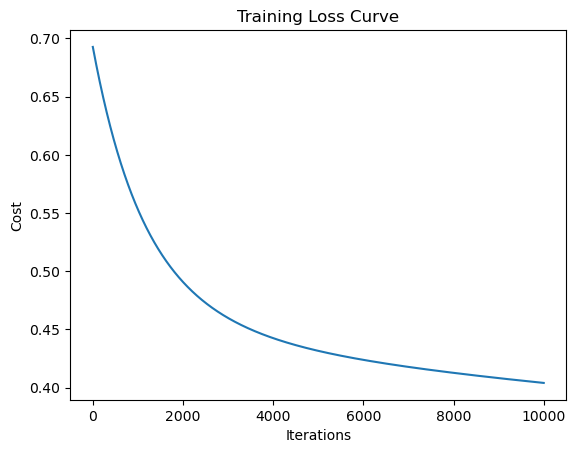

In [42]:
# Plot cost vs iterations for both
plt.plot(costs)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Training Loss Curve")
plt.show()

#### **(1 point)** Step F – Prediction

**Write a prediction function:**

- Perform forward propagation through both the hidden layer and the output layer, using the trained parameters (W1, b1, W2, b2).

- Use the final output of the network (A2) as the prediction probability.

- Convert to binary predictions: output 1 if A2 > 0.5, and 0 otherwise.

Use your training function to obtain W1, b1, W2, b2, and then use your prediction function to make predictions on both the training and testing sets. Then, **report accuracy as the percentage of predictions the model classified correctly.**

In [44]:
def predict(X, W1, b1, W2, b2):
    A1, A2 = forward_propagation(X, W1, b1, W2, b2)
    # Convert probabilities to binary predictions
    A2_binary = (A2 > 0.5).astype(int)
    return A2_binary

In [45]:
# Make predictions
y_train_pred = predict(X_train_std, W1, b1, W2, b2)
y_test_pred = predict(X_test_std, W1, b1, W2, b2)

# Report accuracy
def compute_accuracy(y_true, y_pred):
    """
    Compute classification accuracy
    """
    y_true = y_true.reshape(-1, 1)
    accuracy = np.mean(y_true == y_pred) * 100
    return accuracy
train_acc = compute_accuracy(y_train, y_train_pred)
test_acc = compute_accuracy(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")

Training Accuracy: 84.52%
Test Accuracy: 84.34%


4. **(1 point)** Build the same neural network as in problem (3), but with scikit-learn.

    Instead of coding everything from scratch, we can use scikit-learn’s MLPClassifier (from sklearn.neural_network), which provides a convenient interface for building and training feedforward neural networks, and allows us to easily create models that are much more complex.

    4a) Using MLPClassifier (refer to the documentation), create a neural network with the following:

    - One hidden layer of 3 neurons that uses the sigmoid activation function ('logistic') in the hidden layer.

    - Select 'sgd' as the solver (this is stochastic gradient descent - "regular" gradient descent isn't an option in this package).

    - Set random_state to 44 within the MLPClassifier

    - Use a learning rate of 0.001 and a maximum number of iterations of 10,000


    4b) Train the model on the training data, and use the trained model to predict both training and testing labels. **Report the accuracy on both sets and compare it with the accuracy you reported in problem (3).** *Note: you can either compute the accuracy the way you did in previous questions, or you can use accuracy_score from sklearn.metrics.*

In [46]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Define the model
mlp = MLPClassifier(
    hidden_layer_sizes=(3,),     # one hidden layer with 3 neurons
    activation='logistic',       # sigmoid activation
    solver='sgd',                # stochastic gradient descent
    learning_rate_init=0.001,    # learning rate
    max_iter=10000,              # number of iterations
    random_state=44
)

# Fit on training data
mlp.fit(X_train_std, y_train)

# Make predictions
# Training predictions
y_train_pred_sklearn = mlp.predict(X_train_std)
# Testing predictions
y_test_pred_sklearn = mlp.predict(X_test_std)

# Caclulate and report accuracy
train_acc_sklearn = accuracy_score(y_train, y_train_pred_sklearn) * 100
test_acc_sklearn = accuracy_score(y_test, y_test_pred_sklearn) * 100

print(f"Training Accuracy (sklearn): {train_acc_sklearn:.2f}%")
print(f"Test Accuracy (sklearn): {test_acc_sklearn:.2f}%")


Training Accuracy (sklearn): 84.52%
Test Accuracy (sklearn): 84.34%
